# Benchmarking



### Load Dependencies

In [1]:
import Pkg
deps = Pkg.project().dependencies
for pkg in ["DataFrames", "CSV", "Plots"]
    if !haskey(deps, pkg)
        Pkg.add(pkg)
    end
end

using CSV
using DataFrames
using Random
using Plots
using Plots.PlotMeasures
using ProgressMeter
using Statistics
gr()

include("../src/FPGrowth.jl")
using .FPGrowth
include("../src/logger.jl")
include("../src/utils.jl")
include("../src/eval.jl")
using .Utils
logger = Logger()


success(logger, "Dependencies loaded")


[success] Dependencies loaded


## 1. Connect-4

### Overview

* **Tên tập dữ liệu:** Connect-4 Dataset
* **Nguồn cung cấp:** UCI Machine Learning Repository
* **Tác giả/Người đóng góp:** John Tromp (1995)
* **Số lượng mẫu (Instances):** 67.557
* **Số lượng đặc trưng (Features):** 42 (không tính cột nhãn)
* **Giá trị khuyết thiếu (Missing Values):** Không có (0%)


### Description 

Tập dữ liệu này không lưu trữ toàn bộ các ván cờ từ đầu đến cuối, mà tập trung snapshot tất cả các trạng thái hợp lệ của bàn cờ Connect-4 (kích thước 7 cột x 6 hàng) chính xác tại thời điểm sau 8 nước đi (8-ply positions).

Trạng thái bàn cờ trong tập dữ liệu thỏa mãn hai điều kiện sau:

1. Chưa có bất kỳ người chơi nào giành chiến thắng tại thời điểm nước thứ 8.
2. Nước đi tiếp theo không mang tính bắt buộc (not forced) – nghĩa là ván cờ vẫn mang tính chiến thuật cao và người chơi có nhiều hơn một sự lựa chọn.

Theo quy ước của tập dữ liệu, người đi trước được gắn nhãn là `x` và người đi sau là `o`.


### Attribute information 

Dữ liệu được biểu diễn dưới dạng Categorical table với tổng cộng 43 cột:

* **Input characteristics (42 cột):** Tương ứng với 42 ô vuông trên bàn cờ. Mỗi ô sẽ lưu trữ một trong ba giá trị:
    * `x`: Ô đã được người chơi thứ nhất đánh.
    * `o`: Ô đã được người chơi thứ hai đánh.
    * `b`: Ô trống.


* **Class Label:** Cột cuối cùng thể hiện kết quả lý thuyết trò chơi dành cho người chơi thứ nhất (`x`), với giả định rằng cả hai người chơi đều thực hiện các chiến thuật lý tưởng nhất từ nước thứ 9 trở đi. Cột được phân chia thành 3 lớp:
    * `win`: x chắc chắn thắng (44.473 mẫu, chiếm khoảng 65.83%).
    * `loss`: x chắc chắn thua (16.635 mẫu, chiếm khoảng 24.62%).
    * `draw`: x chắn chắn hòa a (6.449 mẫu, chiếm khoảng 9.55%).



### Characteristics in Data Mining

Nếu sử dụng tập dữ liệu để benchmarking thuật toán, đây là những đặc điểm học thuật cần nhấn mạnh:

* **Dense Dataset:** Không giống với dữ liệu giao dịch bán lẻ thường rất "thưa thớt" (sparse), Connect-4 là một tập dữ liệu cực kỳ "dày đặc" (dense). Mỗi dòng dữ liệu luôn có độ dài cố định.
* **The Challenge of the Hybrid Explosion:** Sự phân bố lặp lại của các giá trị `x`, `o`, `b` khiến các items có tần suất xuất hiện cùng nhau cực kỳ cao. Điều này sinh ra vô số các "tập phổ biến dài" (long frequent itemsets) khi khai thác luật kết hợp (association rules).



### Transform Data 

In [2]:
# zip_file = "../data/benchmark/connect+4.zip"
# extract_directory = "../data/benchmark/connect+4/"
# input_path = "connect-4.data"
# output_path = "../data/benchmark/connect-4.dat"

# Utils.transform_spmf(zip_file, extract_directory, input_path, output_path, logger)


### Configure Paramaters

In [2]:
config = Dict{String, Any}(
    "dataset_path"         => "../data/benchmark/connect-4.dat",
    "java_path" => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    
    "spmf_path"        => "../spmf.jar",
    "baseline_result"     => "../results/connect4_spmf_out.txt",
    "performance_result"      => "../results/connect4_performance.csv",
    "scalability_result" => "../results/connect4_scalability.csv",
    "proposed_result" => "../results/connect4_julia_out.txt",
    "min_sups"                   => [0.75, 0.80, 0.85, 0.9, 0.95],
    "n_executes"           => 5,
    "data_ratios"                => [0.1, 0.25, 0.50, 0.75, 1.0],
    "Minimum Support" => 0.90,
)
success(logger, "Config loaded")


[success] Config loaded


### Evaluate Correctness

In [3]:
correctness_results = eval_correctness(config, logger, algo=FPGrowth.fpgrowth_opt)



__________________________________________________
[phase]  CORRECTNESS
__________________________________________________
[info] Verify accuracy at the threshold MinSup=90.0%
[process] Executing Julia From Scratch (Proposed)...
[process] Executing SPMF Built-in (Baseline)...
[info] Comparing results...


Dict{String, Int64} with 4 entries:
  "Julia_Count"      => 27127
  "SPMF_Count"       => 27127
  "Missing_in_SPMF"  => 0
  "Missing_in_Julia" => 0


__________________________________________________
[phase]  Visualize
__________________________________________________
[success] Correct (27127 frequent itemsets)


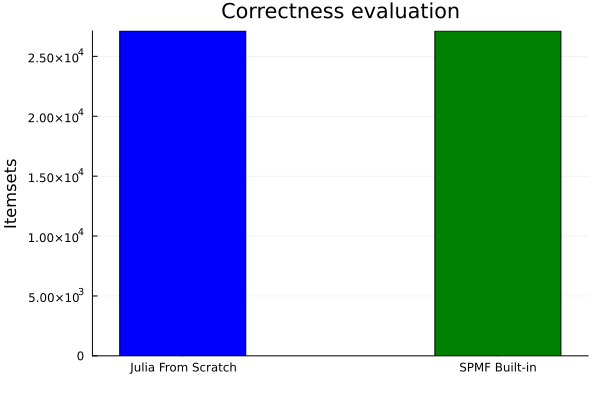

In [4]:
vis_correctness(correctness_results, logger)


### Evaluate Performance

In [5]:
# ── Evaluation: Performance (Time & Memory vs MinSup) ────────────────────────
performance_result = eval_performance(config, logger, algo=FPGrowth.fpgrowth_opt)


[process] Warming up JIT Compiler...

__________________________________________________
[phase]  PERFORMANCE
__________________________________________________
[info] Transactions: 67557
[process] Executing with min_sup = 75.0% in 5 times...
   [metric] Julia From Scratch (Proposed)  → Time: 2.561s | Memory: 774.13 MB | Itemsets: 1585551
   [metric] SPMF Built-in (Baseline)  → Time: 1.52s | Memory: 81.23 MB
[process] Executing with min_sup = 80.0% in 5 times...
   [metric] Julia From Scratch (Proposed)  → Time: 0.653s | Memory: 276.76 MB | Itemsets: 533975
   [metric] SPMF Built-in (Baseline)  → Time: 1.162s | Memory: 99.17 MB


Benchmarking...  40%|███████████████                    |  ETA: 0:00:37

[process] Executing with min_sup = 85.0% in 5 times...


Benchmarking...  60%|██████████████████████             |  ETA: 0:00:19

   [metric] Julia From Scratch (Proposed)  → Time: 0.216s | Memory: 104.74 MB | Itemsets: 142127
   [metric] SPMF Built-in (Baseline)  → Time: 0.752s | Memory: 79.07 MB
[process] Executing with min_sup = 90.0% in 5 times...


Benchmarking...  80%|█████████████████████████████      |  ETA: 0:00:08

   [metric] Julia From Scratch (Proposed)  → Time: 0.166s | Memory: 56.52 MB | Itemsets: 27127
   [metric] SPMF Built-in (Baseline)  → Time: 0.557s | Memory: 96.06 MB
[process] Executing with min_sup = 95.0% in 5 times...


Benchmarking... 100%|███████████████████████████████████| Time: 0:00:35


   [metric] Julia From Scratch (Proposed)  → Time: 0.129s | Memory: 44.17 MB | Itemsets: 2201
   [metric] SPMF Built-in (Baseline)  → Time: 0.514s | Memory: 76.0 MB
[success] Saved at ../results/connect4_performance.csv


Row,MinSup,Itemsets,JuliaTime,JuliaMemory,SPMFTime,SPMFMemory
,Float64,Int64,Float64,Float64,Float64,Float64
1,0.75,1585551,2.56056,774.13,1.52,81.2318
2,0.8,533975,0.653112,276.758,1.162,99.1668
3,0.85,142127,0.216087,104.736,0.752,79.0667
4,0.9,27127,0.165744,56.52,0.557,96.0633
5,0.95,2201,0.128996,44.1689,0.514,76.0



__________________________________________________
[phase]  visualize output size
__________________________________________________


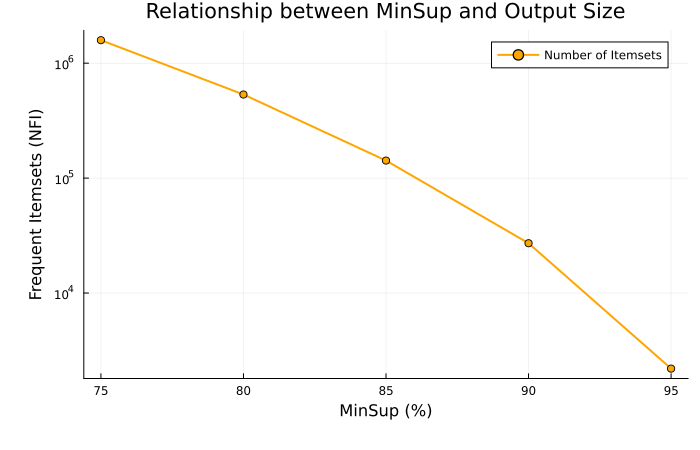

In [14]:
vis_minSupNFI(performance_result, logger)



__________________________________________________
[phase]  visualize
__________________________________________________


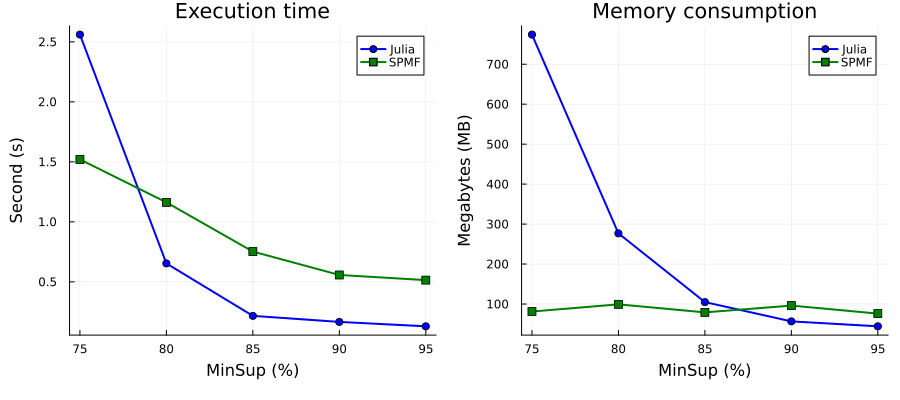

In [6]:
# ── Visualise Performance ─────────────────────────────────────────────────────
vis_performance(performance_result, logger)


### Evaluate Scalability

In [8]:
# ── Evaluation: Scalability (Time vs Data Size) ──────────────────────────────
scalability_result = eval_scalability(config, logger, algo=FPGrowth.fpgrowth_opt)


[process] Warming up JIT Compiler...

__________________________________________________
[phase]  SCALABILITY
__________________________________________________
[info] Minimum Support=90.0%
[process] Data Ratio = 10.0% (6756 giao dịch) ...
   [metric] Julia From Scratch (Proposed) Time: 2.462s | SPMF Built-in (Baseline) Time: 0.993s
[process] Data Ratio = 25.0% (16890 giao dịch) ...


Benchmarking...  40%|███████████████                    |  ETA: 0:00:09

   [metric] Julia From Scratch (Proposed) Time: 0.386s | SPMF Built-in (Baseline) Time: 0.623s
[process] Data Ratio = 50.0% (33779 giao dịch) ...


Benchmarking...  60%|██████████████████████             |  ETA: 0:00:05

   [metric] Julia From Scratch (Proposed) Time: 0.142s | SPMF Built-in (Baseline) Time: 0.556s
[process] Data Ratio = 75.0% (50668 giao dịch) ...


Benchmarking...  80%|█████████████████████████████      |  ETA: 0:00:02

   [metric] Julia From Scratch (Proposed) Time: 0.145s | SPMF Built-in (Baseline) Time: 0.564s
[process] Data Ratio = 100.0% (67557 giao dịch) ...


Benchmarking... 100%|███████████████████████████████████| Time: 0:00:11


   [metric] Julia From Scratch (Proposed) Time: 0.175s | SPMF Built-in (Baseline) Time: 0.563s
[success] Saved at ../results/connect4_scalability.csv


Row,DataRatio,NumTransactions,JuliaTime,SPMFTime
,Float64,Int64,Float64,Float64
1,0.1,6756,2.46217,0.993
2,0.25,16890,0.386072,0.623
3,0.5,33779,0.141921,0.556
4,0.75,50668,0.145329,0.564
5,1.0,67557,0.175293,0.563



__________________________________________________
[phase]  visualize
__________________________________________________


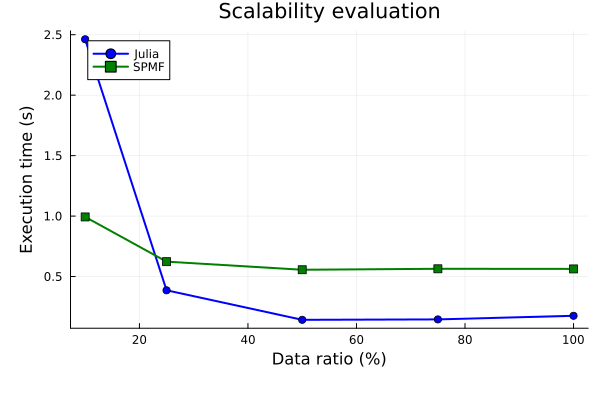

In [9]:
# ── Visualise Scalability ─────────────────────────────────────────────────────
vis_scalability(scalability_result, logger)


### Result

<!-- Bảng bên dưới hiển thị dữ liệu benchmark thô trực tiếp từ DataFrame. -->

In [ ]:
println("__PERFORMANCE__")
display(performance_result)
println()
println("__SCALABILITY__")
display(scalability_result)


## 2. T10I4D100K

### Overview

* **Tên tập dữ liệu:** T10I4D100K
* **Nguồn cung cấp:** IBM Almaden Quest Research Group
* **Tác giả/Người đóng góp:** Agrawal và Srikant (1994)
* **Số lượng mẫu (Transactions):** 100.000
* **Số lượng mục (Distinct Items):** ~870 đến 1.000 mục
* **Giá trị khuyết thiếu (Missing Values):** Không áp dụng (Dạng dữ liệu giao dịch)

---

### Description 

Tập dữ liệu này là một dataset **tổng hợp (synthetic)**, được tạo ra bằng trình giả lập của IBM để mô phỏng hành vi mua sắm thực tế của khách hàng tại các hệ thống bán lẻ. Không giống như các tập dữ liệu quan sát thực tế, T10I4D100K được thiết kế với các tham số điều khiển cụ thể để đánh giá hiệu năng của các thuật toán khai thác tập mục thường xuyên.

Các tham số kỹ thuật định hình tập dữ liệu này bao gồm:
1. **T10 (Average Transaction Size):** Kích thước trung bình của mỗi giao dịch là 10 mục.
2. **I4 (Average Size of Maximal Frequent Itemsets):** Độ dài trung bình của các tập mục thường xuyên tiềm năng tối đa là 4 mục.
3. **D100K (Total Number of Transactions):** Tổng quy mô bộ dữ liệu đạt ngưỡng 100.000 dòng giao dịch.

Dữ liệu mô phỏng quy luật "giỏ hàng": một số nhóm mặt hàng có xác suất xuất hiện cùng nhau rất cao, tạo ra các mẫu hình có ý nghĩa cho việc khai thác luật kết hợp.

---

### Attribute Information 

Dữ liệu được biểu diễn dưới dạng **Transactional format** (dữ liệu dạng dòng, độ dài biến thiên):

* **Input characteristics:** Mỗi dòng đại diện cho một giao dịch, chứa danh sách các mã định danh mặt hàng (Item IDs).
    * Mỗi số nguyên là một **Item ID**.
    * Các mục trong cùng một dòng được phân tách bằng khoảng trắng.
    * Độ dài mỗi dòng không cố định (dao động xung quanh giá trị trung bình là 10).
* **Class Label:** Không có cột nhãn (Unsupervised Learning). Mục tiêu của tập dữ liệu là tìm ra các mối quan hệ tiềm ẩn giữa các mặt hàng thay vì dự báo một giá trị mục tiêu cụ thể.

---

### Characteristics in Data Mining

Nếu sử dụng tập dữ liệu này để benchmarking thuật toán, đây là những đặc điểm học thuật cần nhấn mạnh:

* **Sparse Dataset:** Trái ngược hoàn toàn với các bộ dữ liệu dày đặc (như Connect-4 hay Chess), đây là một tập dữ liệu **"thưa thớt" (sparse)**. Với không gian mục lớn nhưng số mục mỗi giao dịch nhỏ, mật độ dữ liệu rất thấp, phản ánh đúng thực tế của các hệ thống bán lẻ quy mô lớn.
* **Benchmark Standard for Scalability:** Đây là "bài thử" tiêu chuẩn để đo lường khả năng mở rộng (scalability) của các thuật toán như **Apriori, FP-Growth, Eclat** và đặc biệt là các thuật toán khai thác tập đóng như **dCHARM**.
* **Sensitivity to Minimum Support:** Do tính chất thưa, các thuật toán chạy trên tập dữ liệu này rất nhạy cảm với ngưỡng hỗ trợ tối thiểu (*min_sup*). Khi hạ thấp *min_sup*, số lượng tập mục thường xuyên có thể tăng theo hàm mũ, giúp kiểm tra khả năng quản lý bộ nhớ và tối ưu hóa cấu trúc dữ liệu của thuật toán.

---

### Why Choose This Dataset?

Việc lựa chọn T10I4D100K cho mục đích benchmarking thuật toán FP-Growth dựa trên các lý do chiến lược sau:

* **Đánh giá tính đa dạng (Data Diversity):** Sau khi thử nghiệm trên các tập dữ liệu **Dense** (dày đặc) như Connect-4 và Chess, việc chạy trên một tập **Sparse** (thưa thớt) như T10I4D100K giúp khẳng định thuật toán hoạt động ổn định trên nhiều kiểu phân phối dữ liệu khác nhau.
* **Kiểm tra khả năng mở rộng (Scalability):** Với quy mô **100.000 giao dịch**, tập dữ liệu này lớn hơn đáng kể về mặt số lượng dòng so với các tập dữ liệu thực tế thông thường. Đây là "bài test" quan trọng để đánh giá hiệu quả nén của cấu trúc cây **FP-Tree** và tốc độ duyệt đệ quy khi khối lượng dữ liệu đầu vào tăng lên.
* **Thước đo chuẩn quốc tế (Gold Standard):** T10I4D100K là tập dữ liệu chuẩn được công nhận rộng rãi trong cộng đồng nghiên cứu Data Mining. Sử dụng dữ liệu này giúp kết quả benchmarking có tính khách quan cao, dễ dàng so sánh hiệu năng của bản cài đặt Julia với các thư viện tiêu chuẩn như SPMF hay các nghiên cứu khoa học khác.
* **Kiểm soát ngưỡng Support:** Do đặc tính thưa thớt, thuật toán có thể chạy được ở các ngưỡng **minsup rất thấp** mà không bị bùng nổ bộ nhớ ngay lập tức, cho phép quan sát chi tiết hơn sự thay đổi của thời gian thực thi theo độ hỗ trợ.

### Configure Paramaters

In [42]:
config = Dict{String, Any}(
    "dataset_path"         => "../data/benchmark/transactional_T10I4D100K.csv", 
    "java_path"            => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    "spmf_path"            => "../spmf.jar",
    "proposed_result"      => "../results/t10i4d100k_julia_out.txt",  
    "baseline_result"      => "../results/t10i4d100k_spmf_out.txt",
    "performance_result"   => "../results/t10i4d100k_performance.csv",
    "scalability_result"   => "../results/t10i4d100k_scalability.csv",
    "min_sups"             => [0.01, 0.02, 0.03, 0.04, 0.05], 
    "n_executes"           => 5,
    "data_ratios"          => [0.1, 0.25, 0.50, 0.75, 1.0],
    "Minimum Support"      => 0.05,
)

success(logger, "Config loaded")


[success] Config loaded


### Evaluation Correctness


__________________________________________________
[phase]  CORRECTNESS
__________________________________________________
[info] Verify accuracy at the threshold MinSup=5.0%
[process] Executing Julia From Scratch (Proposed)...
[process] Executing SPMF Built-in (Baseline)...
[info] Comparing results...

__________________________________________________
[phase]  Visualize
__________________________________________________
[success] Correct (10 frequent itemsets)


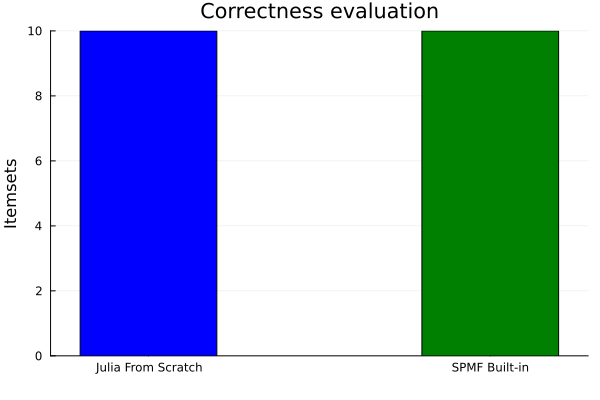

In [43]:
correctness_results = eval_correctness(config, logger, algo=FPGrowth.fpgrowth_opt)
vis_correctness(correctness_results, logger)


### Evaluate Performance

In [ ]:
# ── Evaluation: Performance (Time & Memory vs MinSup) ────────────────────────
performance_result = eval_performance(config, logger, algo=FPGrowth.fpgrowth_opt)


In [ ]:
vis_minSupNFI(performance_results, logger)


In [ ]:
# ── Visualise Performance ─────────────────────────────────────────────────────
vis_performance(performance_result, logger)


### Evaluate Scalability

In [ ]:
# ── Evaluation: Scalability (Time vs Data Size) ──────────────────────────────
scalability_result = eval_scalability(config, logger, algo=FPGrowth.fpgrowth_opt)


In [ ]:
# ── Visualise Scalability ─────────────────────────────────────────────────────
vis_scalability(scalability_result, logger)


### Result

<!-- Bảng bên dưới hiển thị dữ liệu benchmark thô trực tiếp từ DataFrame. -->

In [ ]:
println("__PERFORMANCE__")
display(performance_result)
println()
println("__SCALABILITY__")
display(scalability_result)


## 3. T20I6D100K

### Overview

* **Tên tập dữ liệu:** T20I6D100K Dataset
* **Nguồn cung cấp:** IBM Quest Synthetic Data Generator
* **Số lượng mẫu (Instances):** 99,910 giao dịch
* **Số lượng Items:** 893 
* **Giá trị khuyết thiếu (Missing Values):** Không có (0%)


### Description 

Tập dữ liệu T20I6D100K là một tập dữ liệu tổng hợp (synthetic dataset) được sử dụng phổ biến trong khai thác luật kết hợp (Association Rule Mining), đặc biệt để đánh giá hiệu năng của các thuật toán như Apriori, FP-Growth.

Dữ liệu được sinh ra bằng bộ sinh dữ liệu của IBM nhằm mô phỏng hành vi mua hàng trong thực tế, trong đó mỗi dòng biểu diễn một giao dịch gồm nhiều item (được mã hóa bằng số nguyên).

Các item trong cùng một giao dịch thường có xu hướng xuất hiện cùng nhau theo các pattern ẩn, giúp kiểm thử khả năng phát hiện luật kết hợp của thuật toán.


### Attribute information 

Dữ liệu được biểu diễn dưới dạng Transactional Database:

* **Input characteristics:**
  * Mỗi dòng là một giao dịch (transaction).
  * Mỗi giao dịch bao gồm một tập các item (dạng số nguyên, ví dụ: `1 5 23 67 ...`).
  * Số lượng item trong mỗi giao dịch là biến thiên (không cố định), trung bình khoảng 20 items.

* **Class Label:** Không có (unsupervised dataset).


### Characteristics in Data Mining

Nếu sử dụng tập dữ liệu để benchmarking thuật toán, đây là những đặc điểm học thuật cần nhấn mạnh:

* **Sparse Dataset:** Không giống như các bảng dữ liệu dạng ma trận, T20I6D100K là dữ liệu "thưa" (sparse), vì mỗi transaction chỉ chứa một phần nhỏ trong tổng số tất cả các items có thể có.

* **Scalability Benchmark:** Với 100.000 giao dịch, dataset này thường được dùng để đánh giá khả năng mở rộng (scalability) của thuật toán khai thác luật kết hợp.

* **Controlled Pattern Structure:** Dữ liệu được sinh ra có kiểm soát, đảm bảo tồn tại các frequent itemsets với kích thước trung bình khoảng 6, giúp kiểm tra độ chính xác của thuật toán.

* **Challenge of Candidate Explosion:** Khi minsup thấp, số lượng candidate itemsets tăng rất nhanh (combinatorial explosion), gây áp lực lớn lên bộ nhớ và thời gian xử lý.

* **Suitable for Performance Testing:** Đây là dataset tiêu chuẩn để so sánh tốc độ và hiệu năng giữa các thuật toán như Apriori, Eclat và FP-Growth.

### Configure Paramaters

In [2]:
config = Dict{String, Any}(
    "dataset_path"         => "../data/benchmark/transactional_T20I6D100K.csv", 
    "java_path"            => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    "spmf_path"            => "../spmf.jar",
    "proposed_result"      => "../results/T20I6D100K_julia_out.txt",  
    "baseline_result"      => "../results/T20I6D100K_spmf_out.txt",
    "performance_result"   => "../results/T20I6D100K_performance.csv",
    "scalability_result"   => "../results/T20I6D100K_scalability.csv",
    "min_sups"             => [0.01, 0.02, 0.03, 0.04, 0.05], 
    "n_executes"           => 5,
    "data_ratios"          => [0.1, 0.25, 0.50, 0.75, 1.0],
    "Minimum Support"      => 0.05,
)

success(logger, "Config loaded")


[success] Config loaded


### Evaluate Correctness

In [3]:
correctness_results = eval_correctness(config, logger, algo=FPGrowth.fpgrowth_opt)




__________________________________________________
[phase]  CORRECTNESS
__________________________________________________
[info] Verify accuracy at the threshold MinSup=5.0%
[process] Executing Julia From Scratch (Proposed)...
[process] Executing SPMF Built-in (Baseline)...
[info] Comparing results...


Dict{String, Int64} with 4 entries:
  "Julia_Count"      => 99
  "SPMF_Count"       => 99
  "Missing_in_SPMF"  => 0
  "Missing_in_Julia" => 0


__________________________________________________
[phase]  Visualize
__________________________________________________
[success] Correct (99 frequent itemsets)


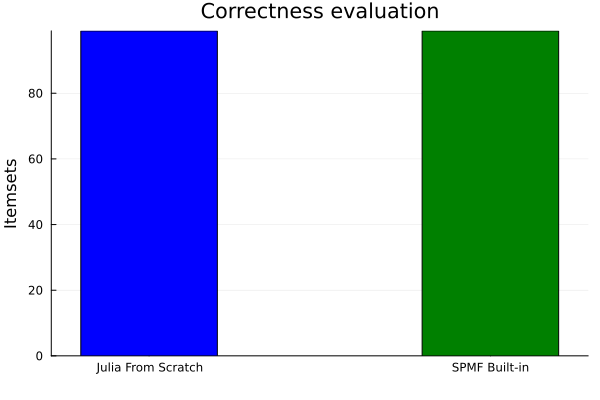

In [4]:
vis_correctness(correctness_results, logger)


### Evaluate Performance

In [5]:
# ── Evaluation: Performance (Time & Memory vs MinSup) ────────────────────────
performance_result = eval_performance(config, logger, algo=FPGrowth.fpgrowth_opt)


[process] Warming up JIT Compiler...

__________________________________________________
[phase]  PERFORMANCE
__________________________________________________
[info] Transactions: 99910
[process] Executing with min_sup = 1.0% in 5 times...
   [metric] Julia From Scratch (Proposed)  → Time: 2.844s | Memory: 243.33 MB | Itemsets: 1523
   [metric] SPMF Built-in (Baseline)  → Time: 4.291s | Memory: 324.85 MB
[process] Executing with min_sup = 2.0% in 5 times...
   [metric] Julia From Scratch (Proposed)  → Time: 1.753s | Memory: 200.06 MB | Itemsets: 378
   [metric] SPMF Built-in (Baseline)  → Time: 3.444s | Memory: 592.34 MB


Benchmarking...  40%|███████████████                    |  ETA: 0:01:01

[process] Executing with min_sup = 3.0% in 5 times...


Benchmarking...  60%|██████████████████████             |  ETA: 0:00:36

   [metric] Julia From Scratch (Proposed)  → Time: 1.29s | Memory: 154.09 MB | Itemsets: 242
   [metric] SPMF Built-in (Baseline)  → Time: 2.514s | Memory: 402.52 MB
[process] Executing with min_sup = 4.0% in 5 times...


Benchmarking...  80%|█████████████████████████████      |  ETA: 0:00:16

   [metric] Julia From Scratch (Proposed)  → Time: 0.605s | Memory: 103.0 MB | Itemsets: 154
   [metric] SPMF Built-in (Baseline)  → Time: 1.776s | Memory: 183.23 MB
[process] Executing with min_sup = 5.0% in 5 times...


Benchmarking... 100%|███████████████████████████████████| Time: 0:01:10


   [metric] Julia From Scratch (Proposed)  → Time: 0.391s | Memory: 61.87 MB | Itemsets: 99
   [metric] SPMF Built-in (Baseline)  → Time: 1.72s | Memory: 61.88 MB
[success] Saved at ../results/T20I6D100K_performance.csv


Row,MinSup,Itemsets,JuliaTime,JuliaMemory,SPMFTime,SPMFMemory
,Float64,Int64,Float64,Float64,Float64,Float64
1,0.01,1523,2.84374,243.333,4.291,324.845
2,0.02,378,1.75283,200.056,3.444,592.343
3,0.03,242,1.29006,154.087,2.514,402.518
4,0.04,154,0.605017,103.003,1.776,183.231
5,0.05,99,0.391059,61.8654,1.72,61.8814



__________________________________________________
[phase]  visualize output size
__________________________________________________


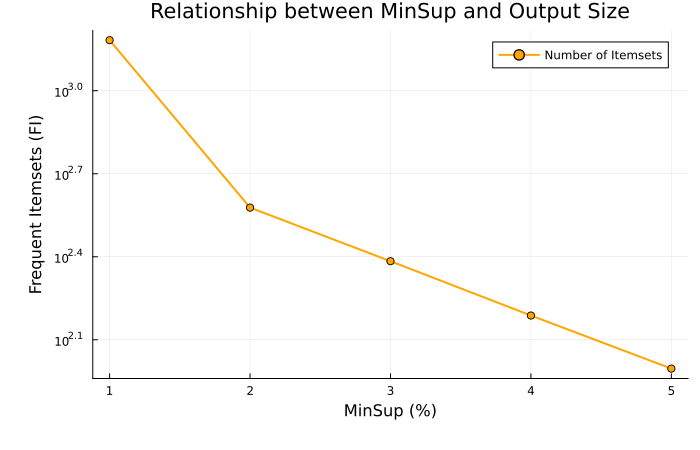

In [6]:
vis_minSupNFI(performance_result, logger)



__________________________________________________
[phase]  visualize
__________________________________________________


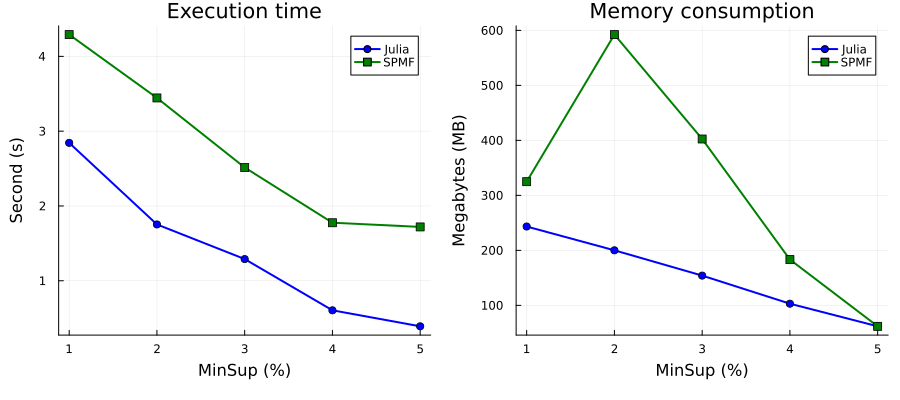

In [7]:
# ── Visualise Performance ─────────────────────────────────────────────────────
vis_performance(performance_result, logger)


### Evaluate Scalability

In [8]:
# ── Evaluation: Scalability (Time vs Data Size) ──────────────────────────────
scalability_result = eval_scalability(config, logger, algo=FPGrowth.fpgrowth_opt)


[process] Warming up JIT Compiler...

__________________________________________________
[phase]  SCALABILITY
__________________________________________________
[info] Minimum Support=5.0%
[process] Data Ratio = 10.0% (9991 giao dịch) ...
   [metric] Julia From Scratch (Proposed) Time: 0.015s | SPMF Built-in (Baseline) Time: 0.433s
[process] Data Ratio = 25.0% (24978 giao dịch) ...


Benchmarking...  40%|███████████████                    |  ETA: 0:00:07

   [metric] Julia From Scratch (Proposed) Time: 0.056s | SPMF Built-in (Baseline) Time: 1.052s
[process] Data Ratio = 50.0% (49955 giao dịch) ...


Benchmarking...  60%|██████████████████████             |  ETA: 0:00:05

   [metric] Julia From Scratch (Proposed) Time: 0.319s | SPMF Built-in (Baseline) Time: 1.623s
[process] Data Ratio = 75.0% (74933 giao dịch) ...


Benchmarking...  80%|█████████████████████████████      |  ETA: 0:00:03

   [metric] Julia From Scratch (Proposed) Time: 0.388s | SPMF Built-in (Baseline) Time: 1.153s
[process] Data Ratio = 100.0% (99910 giao dịch) ...


Benchmarking... 100%|███████████████████████████████████| Time: 0:00:14


   [metric] Julia From Scratch (Proposed) Time: 0.467s | SPMF Built-in (Baseline) Time: 1.883s
[success] Saved at ../results/T20I6D100K_scalability.csv


Row,DataRatio,NumTransactions,JuliaTime,SPMFTime
,Float64,Int64,Float64,Float64
1,0.1,9991,0.0150886,0.433
2,0.25,24978,0.0555536,1.052
3,0.5,49955,0.31868,1.623
4,0.75,74933,0.388149,1.153
5,1.0,99910,0.467141,1.883



__________________________________________________
[phase]  visualize
__________________________________________________


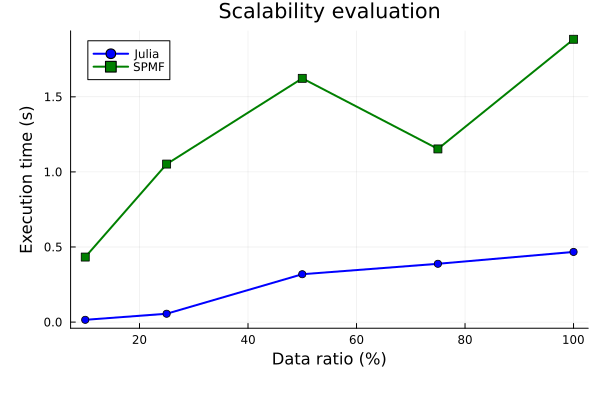

In [9]:
# ── Visualise Scalability ─────────────────────────────────────────────────────
vis_scalability(scalability_result, logger)


### Result

<!-- Bảng bên dưới hiển thị dữ liệu benchmark thô trực tiếp từ DataFrame. -->

In [10]:
println("__PERFORMANCE__")
display(performance_result)
println()
println("__SCALABILITY__")
display(scalability_result)


__PERFORMANCE__


Row,MinSup,Itemsets,JuliaTime,JuliaMemory,SPMFTime,SPMFMemory
,Float64,Int64,Float64,Float64,Float64,Float64
1,0.01,1523,2.84374,243.333,4.291,324.845
2,0.02,378,1.75283,200.056,3.444,592.343
3,0.03,242,1.29006,154.087,2.514,402.518
4,0.04,154,0.605017,103.003,1.776,183.231
5,0.05,99,0.391059,61.8654,1.72,61.8814



__SCALABILITY__


Row,DataRatio,NumTransactions,JuliaTime,SPMFTime
,Float64,Int64,Float64,Float64
1,0.1,9991,0.0150886,0.433
2,0.25,24978,0.0555536,1.052
3,0.5,49955,0.31868,1.623
4,0.75,74933,0.388149,1.153
5,1.0,99910,0.467141,1.883


## 4. Accidents

### Overview

* **Tên tập dữ liệu:** Accidents Dataset
* **Nguồn cung cấp:** FIMI Repository (Frequent Itemset Mining Implementations)
* **Tác giả/Người đóng góp:** Claudio Lucchese, Salvatore Orlando, Raffaele Perego, and Fabrizio Silvestri
* **Số lượng mẫu (Instances):** 340.183
* **Số lượng Items  :** 468


### Description 

Tập dữ liệu Accidents là tập dữ liệu giao dịch được xây dựng từ dữ liệu tai nạn giao thông đã được ẩn danh hóa. Mỗi giao dịch biểu diễn một vụ tai nạn và chứa tập hợp các thuộc tính liên quan đến sự kiện đó.

Các thuộc tính có thể bao gồm các yếu tố như điều kiện thời tiết, loại phương tiện, tình trạng đường, thời điểm xảy ra tai nạn và các yếu tố môi trường khác. Tuy nhiên, do dữ liệu đã được mã hóa dưới dạng item ID, ý nghĩa cụ thể của từng item không được cung cấp trực tiếp.

Tập dữ liệu này thường được sử dụng trong nghiên cứu khai phá luật kết hợp (association rule mining) và khai thác tập phổ biến (frequent itemset mining) nhằm tìm ra các mẫu đồng xuất hiện giữa các yếu tố trong tai nạn giao thông.


### Attribute information 

Dữ liệu được biểu diễn dưới dạng transactional format (FIMI format):

- **Mỗi dòng (transaction):** Đại diện cho một vụ tai nạn.
- **Mỗi item:** Là một số nguyên (ID) đại diện cho một thuộc tính/đặc trưng đã được mã hóa.
- **Không có tên thuộc tính rõ ràng:** Các item không đi kèm semantic label.
- **Độ dài giao dịch trung bình:** Khoảng 33.8 items / transaction.



### Characteristics in Data Mining

Nếu sử dụng tập dữ liệu để benchmarking thuật toán, đây là những đặc điểm học thuật cần nhấn mạnh:

* **Large-scale Dataset:** Với hơn 340k giao dịch, đây là tập dữ liệu lớn, phù hợp để đánh giá hiệu năng và khả năng mở rộng của thuật toán (scalability).
* **No Semantic Labels:** Do không có ý nghĩa cụ thể của item, khó diễn giải kết quả, nhưng phù hợp để benchmark thuật toán thuần túy.
* **Frequent Pattern Richness:** Số lượng item tương đối lớn kết hợp với số transaction lớn, sinh ra nhiều tập phổ biến và luật kết hợp có ý nghĩa thống kê.



### Configure Paramaters

In [11]:
config = Dict{String, Any}(
    "dataset_path"         => "../data/benchmark/accidents.dat", 
    "java_path"            => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    "spmf_path"            => "../spmf.jar",
    "proposed_result"      => "../results/accidents_julia_out.txt",  
    "baseline_result"      => "../results/accidents_spmf_out.txt",
    "performance_result"   => "../results/accidents_performance.csv",
    "scalability_result"   => "../results/accidents_scalability.csv",
    "min_sups"             => [0.3, 0.35, 0.4, 0.45, 0.5], 
    "n_executes"           => 5,
    "data_ratios"          => [0.1, 0.25, 0.50, 0.75, 1.0],
    "Minimum Support"      => 0.5,
)

success(logger, "Config loaded")


[success] Config loaded


### Evaluate Correctness

In [12]:
correctness_results = eval_correctness(config, logger, algo=FPGrowth.fpgrowth_opt)




__________________________________________________
[phase]  CORRECTNESS
__________________________________________________
[info] Verify accuracy at the threshold MinSup=50.0%
[process] Executing Julia From Scratch (Proposed)...
[process] Executing SPMF Built-in (Baseline)...
[info] Comparing results...


Dict{String, Int64} with 4 entries:
  "Julia_Count"      => 8057
  "SPMF_Count"       => 8057
  "Missing_in_SPMF"  => 0
  "Missing_in_Julia" => 0


__________________________________________________
[phase]  Visualize
__________________________________________________
[success] Correct (8057 frequent itemsets)


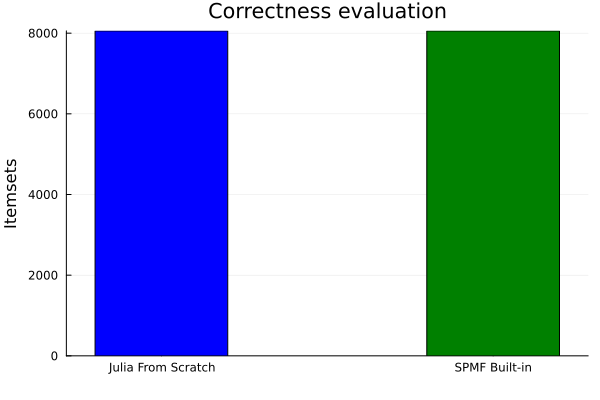

In [13]:
vis_correctness(correctness_results, logger)


### Evaluate Performance

In [14]:
# ── Evaluation: Performance (Time & Memory vs MinSup) ────────────────────────
performance_result = eval_performance(config, logger, algo=FPGrowth.fpgrowth_opt)


[process] Warming up JIT Compiler...

__________________________________________________
[phase]  PERFORMANCE
__________________________________________________
[info] Transactions: 340183
[process] Executing with min_sup = 30.0% in 5 times...
   [metric] Julia From Scratch (Proposed)  → Time: 4.963s | Memory: 484.33 MB | Itemsets: 149545
   [metric] SPMF Built-in (Baseline)  → Time: 4.717s | Memory: 204.53 MB
[process] Executing with min_sup = 35.0% in 5 times...


Benchmarking...  40%|███████████████                    |  ETA: 0:01:25

   [metric] Julia From Scratch (Proposed)  → Time: 3.165s | Memory: 382.23 MB | Itemsets: 68222
   [metric] SPMF Built-in (Baseline)  → Time: 4.293s | Memory: 297.76 MB
[process] Executing with min_sup = 40.0% in 5 times...


Benchmarking...  60%|██████████████████████             |  ETA: 0:00:51

   [metric] Julia From Scratch (Proposed)  → Time: 2.598s | Memory: 307.76 MB | Itemsets: 32528
   [metric] SPMF Built-in (Baseline)  → Time: 3.977s | Memory: 266.29 MB
[process] Executing with min_sup = 45.0% in 5 times...


Benchmarking...  80%|█████████████████████████████      |  ETA: 0:00:24

   [metric] Julia From Scratch (Proposed)  → Time: 2.136s | Memory: 275.19 MB | Itemsets: 16123
   [metric] SPMF Built-in (Baseline)  → Time: 3.378s | Memory: 202.21 MB
[process] Executing with min_sup = 50.0% in 5 times...


Benchmarking... 100%|███████████████████████████████████| Time: 0:01:49


   [metric] Julia From Scratch (Proposed)  → Time: 1.633s | Memory: 243.55 MB | Itemsets: 8057
   [metric] SPMF Built-in (Baseline)  → Time: 2.795s | Memory: 28.45 MB
[success] Saved at ../results/accidents_performance.csv


Row,MinSup,Itemsets,JuliaTime,JuliaMemory,SPMFTime,SPMFMemory
,Float64,Int64,Float64,Float64,Float64,Float64
1,0.3,149545,4.96338,484.333,4.717,204.533
2,0.35,68222,3.16484,382.231,4.293,297.756
3,0.4,32528,2.59823,307.76,3.977,266.29
4,0.45,16123,2.13637,275.186,3.378,202.21
5,0.5,8057,1.63327,243.555,2.795,28.4486



__________________________________________________
[phase]  visualize output size
__________________________________________________


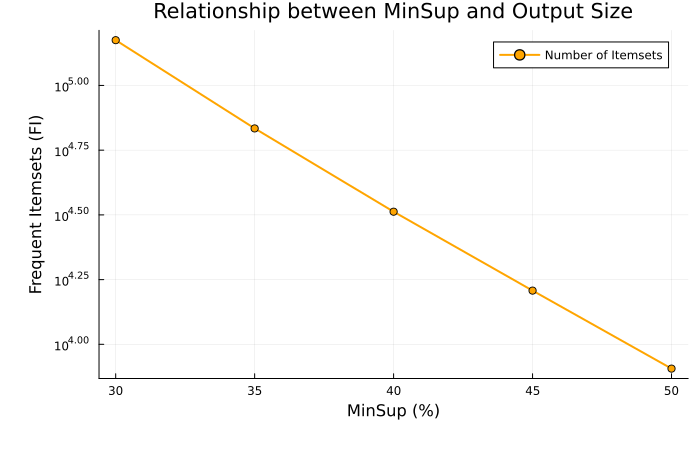

In [15]:
vis_minSupNFI(performance_result, logger)



__________________________________________________
[phase]  visualize
__________________________________________________


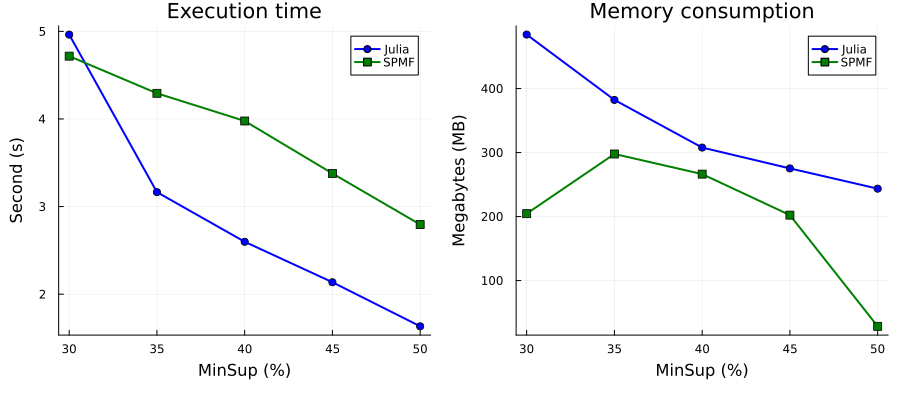

In [16]:
# ── Visualise Performance ─────────────────────────────────────────────────────
vis_performance(performance_result, logger)


### Evaluate Scalability

In [17]:
# ── Evaluation: Scalability (Time vs Data Size) ──────────────────────────────
scalability_result = eval_scalability(config, logger, algo=FPGrowth.fpgrowth_opt)


[process] Warming up JIT Compiler...

__________________________________________________
[phase]  SCALABILITY
__________________________________________________
[info] Minimum Support=50.0%
[process] Data Ratio = 10.0% (34019 giao dịch) ...
   [metric] Julia From Scratch (Proposed) Time: 0.17s | SPMF Built-in (Baseline) Time: 0.899s
[process] Data Ratio = 25.0% (85046 giao dịch) ...


Benchmarking...  40%|███████████████                    |  ETA: 0:00:08

   [metric] Julia From Scratch (Proposed) Time: 0.367s | SPMF Built-in (Baseline) Time: 1.134s
[process] Data Ratio = 50.0% (170092 giao dịch) ...
   [metric] Julia From Scratch (Proposed) Time: 0.701s | SPMF Built-in (Baseline) Time: 1.642s


Benchmarking...  60%|██████████████████████             |  ETA: 0:00:07

[process] Data Ratio = 75.0% (255138 giao dịch) ...
   [metric] Julia From Scratch (Proposed) Time: 1.116s | SPMF Built-in (Baseline) Time: 2.254s


Benchmarking...  80%|█████████████████████████████      |  ETA: 0:00:04

[process] Data Ratio = 100.0% (340183 giao dịch) ...


Benchmarking... 100%|███████████████████████████████████| Time: 0:00:23


   [metric] Julia From Scratch (Proposed) Time: 1.427s | SPMF Built-in (Baseline) Time: 2.89s
[success] Saved at ../results/accidents_scalability.csv


Row,DataRatio,NumTransactions,JuliaTime,SPMFTime
,Float64,Int64,Float64,Float64
1,0.1,34019,0.170079,0.899
2,0.25,85046,0.367233,1.134
3,0.5,170092,0.701014,1.642
4,0.75,255138,1.1162,2.254
5,1.0,340183,1.42714,2.89



__________________________________________________
[phase]  visualize
__________________________________________________


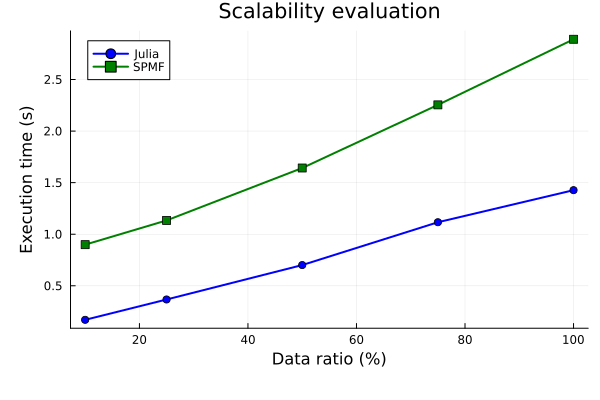

In [18]:
# ── Visualise Scalability ─────────────────────────────────────────────────────
vis_scalability(scalability_result, logger)


### Result

<!-- Bảng bên dưới hiển thị dữ liệu benchmark thô trực tiếp từ DataFrame. -->

In [19]:
println("__PERFORMANCE__")
display(performance_result)
println()
println("__SCALABILITY__")
display(scalability_result)


__PERFORMANCE__


Row,MinSup,Itemsets,JuliaTime,JuliaMemory,SPMFTime,SPMFMemory
,Float64,Int64,Float64,Float64,Float64,Float64
1,0.3,149545,4.96338,484.333,4.717,204.533
2,0.35,68222,3.16484,382.231,4.293,297.756
3,0.4,32528,2.59823,307.76,3.977,266.29
4,0.45,16123,2.13637,275.186,3.378,202.21
5,0.5,8057,1.63327,243.555,2.795,28.4486



__SCALABILITY__


Row,DataRatio,NumTransactions,JuliaTime,SPMFTime
,Float64,Int64,Float64,Float64
1,0.1,34019,0.170079,0.899
2,0.25,85046,0.367233,1.134
3,0.5,170092,0.701014,1.642
4,0.75,255138,1.1162,2.254
5,1.0,340183,1.42714,2.89


## 5. Retails

### Overview

* **Tên tập dữ liệu:** Retail Dataset
* **Nguồn cung cấp:** FIMI Repository (Frequent Itemset Mining Implementations)
* **Tác giả/Người đóng góp:** Karolien Geurts
* **Số lượng mẫu (Instances):** 88.162
* **Số lượng Items  :** 16.470


### Description 

Tập dữ liệu này chứa các giao dịch mua hàng thực tế của khách hàng tại một cửa hàng bán lẻ (retail store) ẩn danh ở Bỉ. Mỗi dòng dữ liệu đại diện cho một giao dịch, bao gồm danh sách các sản phẩm (items) mà khách hàng đã mua cùng lúc.

Dữ liệu không chứa thông tin về thứ tự mua, thời gian, hoặc danh tính khách hàng, mà chỉ tập trung vào sự đồng xuất hiện của các mặt hàng trong cùng một giao dịch.

Tập dữ liệu này thường được sử dụng trong các bài toán khai phá luật kết hợp (association rule mining) và khai thác tập phổ biến (frequent itemset mining) nhằm tìm ra các mẫu mua hàng phổ biến và mối quan hệ giữa các sản phẩm.


### Attribute information 

Dữ liệu được biểu diễn dưới dạng transactional format (FIMI format):

- **Mỗi dòng (transaction):** Đại diện cho một giao dịch mua hàng.
- **Mỗi item:** Là một số nguyên (ID) đại diện cho một sản phẩm.
- **Không có tên sản phẩm cụ thể:** Các item đã được mã hóa.
- **Độ dài giao dịch trung bình:** Khoảng 10.3 items / transaction.



### Characteristics in Data Mining

Nếu sử dụng tập dữ liệu để benchmarking thuật toán, đây là những đặc điểm học thuật cần nhấn mạnh:

* **Real-world Dataset:** Dữ liệu được thu thập từ môi trường thực tế, phản ánh hành vi mua hàng thật của người dùng, không phải dữ liệu tổng hợp.
* **Short Transactions:** Độ dài giao dịch trung bình thấp (~10.3), phù hợp để kiểm tra hiệu quả thuật toán trên dữ liệu thưa.
* **High Dimensionality:** Số lượng item rất lớn (16k+), không gian tìm kiếm rộng, dễ gây bùng nổ số lượng tập phổ biến.
* **Benchmark Standard:** Đây là một trong những dataset kinh điển được sử dụng rộng rãi để đánh giá hiệu năng của các thuật toán như Apriori, FP-Growth, Eclat.



### Configure Paramaters

In [20]:
config = Dict{String, Any}(
    "dataset_path"         => "../data/benchmark/retail.dat", 
    "java_path"            => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    "spmf_path"            => "../spmf.jar",
    "proposed_result"      => "../results/retail_julia_out.txt",  
    "baseline_result"      => "../results/retail_spmf_out.txt",
    "performance_result"   => "../results/retail_performance.csv",
    "scalability_result"   => "../results/retail_scalability.csv",
    "min_sups"             => [0.3, 0.35, 0.4, 0.45, 0.5], 
    "n_executes"           => 5,
    "data_ratios"          => [0.1, 0.25, 0.50, 0.75, 1.0],
    "Minimum Support"      => 0.5,
)

success(logger, "Config loaded")


[success] Config loaded


### Evaluate Correctness

In [21]:
correctness_results = eval_correctness(config, logger, algo=FPGrowth.fpgrowth_opt)




__________________________________________________
[phase]  CORRECTNESS
__________________________________________________
[info] Verify accuracy at the threshold MinSup=50.0%
[process] Executing Julia From Scratch (Proposed)...
[process] Executing SPMF Built-in (Baseline)...
[info] Comparing results...


Dict{String, Int64} with 4 entries:
  "Julia_Count"      => 1
  "SPMF_Count"       => 1
  "Missing_in_SPMF"  => 0
  "Missing_in_Julia" => 0


__________________________________________________
[phase]  Visualize
__________________________________________________
[success] Correct (1 frequent itemsets)


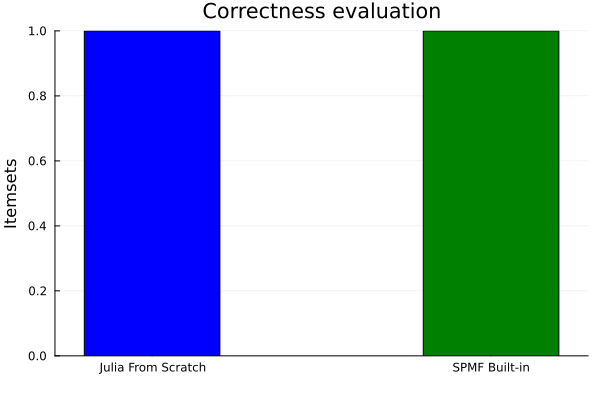

In [22]:
vis_correctness(correctness_results, logger)


### Evaluate Performance

In [23]:
# ── Evaluation: Performance (Time & Memory vs MinSup) ────────────────────────
performance_result = eval_performance(config, logger, algo=FPGrowth.fpgrowth_opt)


[process] Warming up JIT Compiler...

__________________________________________________
[phase]  PERFORMANCE
__________________________________________________
[info] Transactions: 88162
[process] Executing with min_sup = 30.0% in 5 times...
   [metric] Julia From Scratch (Proposed)  → Time: 0.037s | Memory: 7.03 MB | Itemsets: 3
   [metric] SPMF Built-in (Baseline)  → Time: 0.469s | Memory: 56.9 MB
[process] Executing with min_sup = 35.0% in 5 times...


Benchmarking...  40%|███████████████                    |  ETA: 0:00:11

   [metric] Julia From Scratch (Proposed)  → Time: 0.036s | Memory: 7.03 MB | Itemsets: 2
   [metric] SPMF Built-in (Baseline)  → Time: 0.37s | Memory: 56.21 MB
[process] Executing with min_sup = 40.0% in 5 times...


Benchmarking...  60%|██████████████████████             |  ETA: 0:00:07

   [metric] Julia From Scratch (Proposed)  → Time: 0.041s | Memory: 7.03 MB | Itemsets: 2
   [metric] SPMF Built-in (Baseline)  → Time: 0.361s | Memory: 55.69 MB
[process] Executing with min_sup = 45.0% in 5 times...


Benchmarking...  80%|█████████████████████████████      |  ETA: 0:00:04

   [metric] Julia From Scratch (Proposed)  → Time: 0.034s | Memory: 7.03 MB | Itemsets: 2
   [metric] SPMF Built-in (Baseline)  → Time: 0.445s | Memory: 56.19 MB
[process] Executing with min_sup = 50.0% in 5 times...


Benchmarking... 100%|███████████████████████████████████| Time: 0:00:18


   [metric] Julia From Scratch (Proposed)  → Time: 0.032s | Memory: 6.43 MB | Itemsets: 1
   [metric] SPMF Built-in (Baseline)  → Time: 0.397s | Memory: 54.42 MB
[success] Saved at ../results/retail_performance.csv


Row,MinSup,Itemsets,JuliaTime,JuliaMemory,SPMFTime,SPMFMemory
,Float64,Int64,Float64,Float64,Float64,Float64
1,0.3,3,0.0366774,7.02638,0.469,56.8966
2,0.35,2,0.0357233,7.02552,0.37,56.214
3,0.4,2,0.0414931,7.02552,0.361,55.6922
4,0.45,2,0.0336416,7.02549,0.445,56.1941
5,0.5,1,0.0316427,6.4298,0.397,54.4166



__________________________________________________
[phase]  visualize output size
__________________________________________________


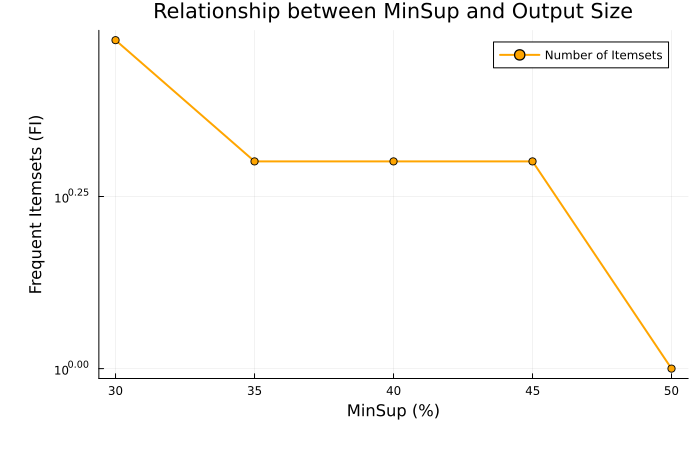

In [24]:
vis_minSupNFI(performance_result, logger)



__________________________________________________
[phase]  visualize
__________________________________________________


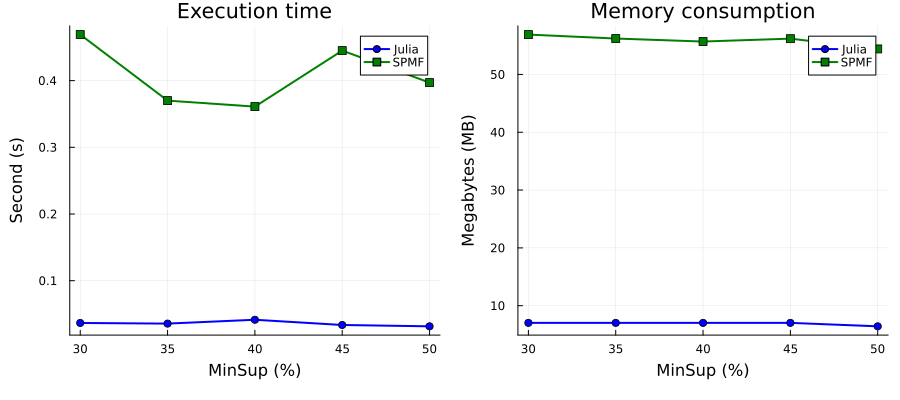

In [25]:
# ── Visualise Performance ─────────────────────────────────────────────────────
vis_performance(performance_result, logger)


### Evaluate Scalability

In [26]:
# ── Evaluation: Scalability (Time vs Data Size) ──────────────────────────────
scalability_result = eval_scalability(config, logger, algo=FPGrowth.fpgrowth_opt)


[process] Warming up JIT Compiler...

__________________________________________________
[phase]  SCALABILITY
__________________________________________________
[info] Minimum Support=50.0%
[process] Data Ratio = 10.0% (8817 giao dịch) ...
   [metric] Julia From Scratch (Proposed) Time: 0.005s | SPMF Built-in (Baseline) Time: 0.132s
[process] Data Ratio = 25.0% (22041 giao dịch) ...


Benchmarking...  40%|███████████████                    |  ETA: 0:00:04

   [metric] Julia From Scratch (Proposed) Time: 0.017s | SPMF Built-in (Baseline) Time: 0.238s
[process] Data Ratio = 50.0% (44081 giao dịch) ...


Benchmarking...  60%|██████████████████████             |  ETA: 0:00:03

   [metric] Julia From Scratch (Proposed) Time: 0.02s | SPMF Built-in (Baseline) Time: 0.268s
[process] Data Ratio = 75.0% (66122 giao dịch) ...


Benchmarking...  80%|█████████████████████████████      |  ETA: 0:00:01

   [metric] Julia From Scratch (Proposed) Time: 0.024s | SPMF Built-in (Baseline) Time: 0.328s
[process] Data Ratio = 100.0% (88162 giao dịch) ...


Benchmarking... 100%|███████████████████████████████████| Time: 0:00:06


   [metric] Julia From Scratch (Proposed) Time: 0.034s | SPMF Built-in (Baseline) Time: 0.42s
[success] Saved at ../results/retail_scalability.csv


Row,DataRatio,NumTransactions,JuliaTime,SPMFTime
,Float64,Int64,Float64,Float64
1,0.1,8817,0.0050175,0.132
2,0.25,22041,0.017395,0.238
3,0.5,44081,0.0204172,0.268
4,0.75,66122,0.0243854,0.328
5,1.0,88162,0.0338849,0.42



__________________________________________________
[phase]  visualize
__________________________________________________


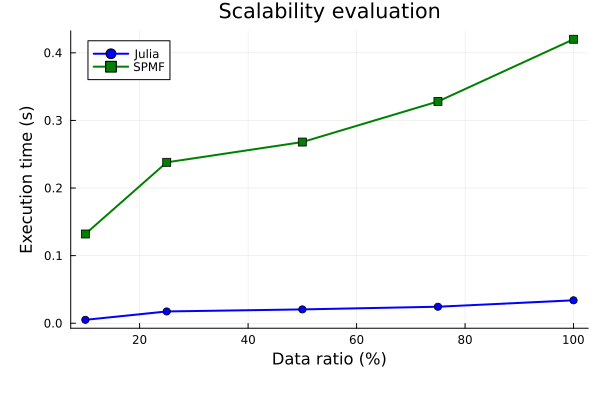

In [27]:
# ── Visualise Scalability ─────────────────────────────────────────────────────
vis_scalability(scalability_result, logger)


### Result

<!-- Bảng bên dưới hiển thị dữ liệu benchmark thô trực tiếp từ DataFrame. -->

In [28]:
println("__PERFORMANCE__")
display(performance_result)
println()
println("__SCALABILITY__")
display(scalability_result)


__PERFORMANCE__


Row,MinSup,Itemsets,JuliaTime,JuliaMemory,SPMFTime,SPMFMemory
,Float64,Int64,Float64,Float64,Float64,Float64
1,0.3,3,0.0366774,7.02638,0.469,56.8966
2,0.35,2,0.0357233,7.02552,0.37,56.214
3,0.4,2,0.0414931,7.02552,0.361,55.6922
4,0.45,2,0.0336416,7.02549,0.445,56.1941
5,0.5,1,0.0316427,6.4298,0.397,54.4166



__SCALABILITY__


Row,DataRatio,NumTransactions,JuliaTime,SPMFTime
,Float64,Int64,Float64,Float64
1,0.1,8817,0.0050175,0.132
2,0.25,22041,0.017395,0.238
3,0.5,44081,0.0204172,0.268
4,0.75,66122,0.0243854,0.328
5,1.0,88162,0.0338849,0.42


### f, Ảnh hưởng của độ dài giao dịch trung bình


__________________________________________________
[phase]  TRANSACTION LENGTH
__________________________________________________
[process] Average Length = 10 items ...
   [metric] AvgLen: 10 | Julia: 0.022s, 0.09MB | SPMF: 0.346s, 63.57MB
[process] Average Length = 20 items ...


Benchmarking Lengths...  50%|██████████████             |  ETA: 0:00:07

   [metric] AvgLen: 20 | Julia: 0.042s, 0.09MB | SPMF: 0.483s, 29.58MB
[process] Average Length = 30 items ...


Benchmarking Lengths...  75%|█████████████████████      |  ETA: 0:00:04

   [metric] AvgLen: 30 | Julia: 0.08s, 0.09MB | SPMF: 0.637s, 102.47MB
[process] Average Length = 40 items ...


Benchmarking Lengths... 100%|███████████████████████████| Time: 0:00:17


   [metric] AvgLen: 40 | Julia: 0.088s, 0.09MB | SPMF: 0.705s, 14.58MB

__________________________________________________
[phase]  visualize
__________________________________________________


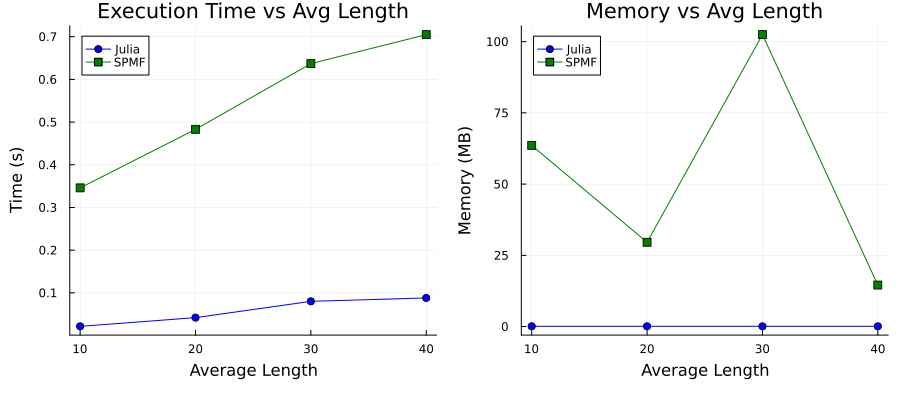

In [29]:
# 1. Nạp lại code (BẮT BUỘC)
include("../src/eval.jl")

# 2. Chạy cấu hình có thêm đo lường Memory
config_f_T20_full = Dict{String, Any}(
    "java_path"        => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    "spmf_path"        => "../spmf.jar",
    "baseline_result"  => "../results/t20_f_spmf_out.txt",
    "num_transactions" => 100000,         # 100k giao dịch
    "universe_size"    => 1000,           
    "avg_lengths"      => [10, 20, 30, 40], 
    "Minimum Support"  => 0.1             # Ngưỡng 10%
)

f_results = eval_tx_length(config_f_T20_full, logger; algo=FPGrowth.fpgrowth_opt)
vis_tx_length(f_results, logger)
